In [ ]:
import pandas as pd
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import  SMAPE, RMSE
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

#Authors: Petter Rignell
#Inspired by: https://pytorch-forecasting.readthedocs.io/en/stable/tutorials/stallion.html

data = pd.read_excel("economic_data1.xlsx")
data = data.sort_values("Date").reset_index(drop=True)

data.head()

c:\Users\pette\AppData\Local\Programs\Python\Python39\lib\site-packages\pytorch_forecasting\models\base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


,Unnamed: 0,Date,Close,High,Low,Open,Volume,RSI,Stoch_Oscillator,ROC_indi,...,thh_growth_missing,tbus_growth_missing,risky_tr_missing,safe_tr_missing,lev_missing,ltd_missing,noncore_missing,Weekday_missing,inverted_yield,inverted_yield_missing
0,0,1982-04-20,115.440002,117.139999,114.830002,115.800003,54610000,56.860303,60.233923,1.450041,...,1,1,1,1,1,1,1,0,0.68,0
1,1,1982-04-21,115.720001,115.870003,115.300003,115.480003,57820000,58.331098,63.473019,0.521194,...,1,1,1,1,1,1,1,0,0.71,0
2,2,1982-04-22,117.190002,117.250000,115.720001,115.720001,64470000,65.065198,78.492223,2.144164,...,1,1,1,1,1,1,1,0,0.70,0
3,3,1982-04-23,118.639999,118.639999,117.190002,118.019997,71840000,70.183825,100.000000,2.843272,...,1,1,1,1,1,1,1,0,0.77,0
4,4,1982-04-24,118.639999,118.639999,117.190002,118.019997,71840000,70.183825,100.000000,2.843272,...,1,1,1,1,1,1,1,1,0.79,0


### Dataloader

In [2]:
time_varying_reals = ["High", "Low", "Open", "Volume", "RSI", "Stoch_Oscillator", "ROC_indi", "MACD", "ADX_indi", "ichimoku_conversion",
"ichimoku_base", "ichimoku_a", "ichimoku_b","SMA_20","SMA_50","SMA_200","Bollinger_HBand","ATR","OBVI", 'DGS10', 'cpi_growth', 'ppi_growth', 
'UMCSENT', 'hpnom_growth','gdp_growth', 'dividend_yield', 'price_to_earnings', 'UNRATE', 'revenue_growth', 'expenditure_growth', 'exports_growth', 'imports_growth', 'thh_growth', 'tbus_growth',
'risky_tr', 'safe_tr', 'lev', 'ltd', 'noncore', 'inverted_yield']

missing_vals_cols = ['DGS10', 'cpi_growth', 'ppi_growth', 'UMCSENT', 'hpnom_growth','gdp_growth', 'dividend_yield', 'price_to_earnings', 'UNRATE', 'revenue_growth', 'expenditure_growth', 'exports_growth', 'imports_growth', 'thh_growth', 'tbus_growth',
'risky_tr', 'safe_tr', 'lev', 'ltd', 'noncore', 'inverted_yield']
missing_cols = []

#Build array with missing value features for transformer context
for col in missing_vals_cols:
    missing_cols.append(f'{col}_missing')
    data[f'{col}_missing'] = data[f'{col}_missing'].astype(str).astype("category")

missing_cols.append("Weekday_missing")
data[f'Weekday_missing'] = data[f'Weekday_missing'].astype(str).astype("category")

data["series_id"] = "S&P500"
data["time_idx"] = range(len(data))

#Train, validate, and test split
n = len(data)
train_end = int(0.75*n)
val_end = int(0.9*n)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

tft_train_data = TimeSeriesDataSet(
    train_data, 
    time_idx="time_idx",
    target='Close',
    group_ids=['series_id'],
    max_prediction_length = 30,
    max_encoder_length = 90,
    time_varying_known_categoricals = missing_cols, 
    time_varying_known_reals= time_varying_reals, 
    time_varying_unknown_reals=["Close"],
    add_relative_time_idx=True,
    add_target_scales= True,
    add_encoder_length=True
)

tft_val_data = TimeSeriesDataSet.from_dataset(
    tft_train_data, val_data, stop_randomization=True, predict=True
)

tft_test_data = TimeSeriesDataSet.from_dataset(
    tft_train_data, test_data, stop_randomization= True, predict=True
)

batch_size = 128

val_loader = tft_val_data.to_dataloader(
    train=False, batch_size=batch_size, num_workers=4, drop_last=False, persistent_workers=True
)

train_loader = tft_train_data.to_dataloader(
    train=True, batch_size=batch_size, num_workers=4, persistent_workers=True,
)

test_loader = tft_test_data.to_dataloader(
    train=False, batch_size=batch_size, num_workers=4, drop_last = False, persistent_workers=True
)

In [ ]:
import lightning.pytorch as pl
import torch
import matplotlib.pyplot as plt

pl.seed_everything(42)

#Save the best model based on validation loss
checkpoint_callback = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min")

#NOTE GPU format 
trainer = pl.Trainer(
    max_epochs=25,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.1,
    enable_model_summary=True,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, mode="min"),  #Early stopping callback
        checkpoint_callback
    ]
)

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

#Hyperparameters for the Temporal Fusion Transformer
tft = TemporalFusionTransformer.from_dataset(
    tft_train_data,
    learning_rate=0.01,                
    hidden_size=32,                     
    attention_head_size=2,              
    dropout=0.2,                        
    hidden_continuous_size=16,         
    output_size=1,                      
    loss=SMAPE(),                       
    log_interval=50,
    reduce_on_plateau_patience=4,         
)

trainer.fit(
    tft, 
    train_dataloaders=train_loader,
    val_dataloaders= val_loader
)

#Return the best model path and load the best model
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\pette\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\pette\AppData\Local\Programs\Python\Python39\lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


CUDA Available: True
GPU: NVIDIA GeForce RTX 3060 Ti


You are using a CUDA device ('NVIDIA GeForce RTX 3060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | SMAPE                           | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 44     | train
3  | prescalers                         | ModuleDict                      | 1.4 K  | train
4  | static_variable_selection        

Epoch 5:  70%|███████   | 64/91 [00:41<00:17,  1.55it/s, v_num=231, train_loss_step=0.00432, val_loss=0.0112, train_loss_epoch=0.00508] 

### Hyperparameter tuning 
case_tuner = optimize_hyperparameters(
    train_dataloaders= train_loader,
    val_dataloaders= val_loader,
    model_path="optuna_test",
    n_trials=25,
    max_epochs=50,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches = 30),
    use_learning_rate_finder=False,
)

#print(case_tuner.best_trial.params)

### Validate

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


R2 Score:  -6.08289098739624
SMAPE 0.13852306
RMSE 767.2102


'#Testing\n#test_predictions = best_tft.predict(test_loader, return_y=True, return_index=True)\n\nraw_predictions = best_tft.predict(\n    test_loader, mode="raw", return_x=True, return_y = True\n)\n\ny_actual = val_predictions.y[0]\ny_actual_np = y_actual.cpu().numpy()\ny_pred_np = val_predictions.output.cpu().numpy()\ny_actual_np = y_actual_np.flatten()\ny_pred_np = y_pred_np.flatten()\nprint("R2 Score: ", r2_score(y_actual_np, y_pred_np))\nprint("SMAPE",SMAPE()(test_predictions.output, test_predictions.y).cpu().numpy())\nprint("RMSE",RMSE()(test_predictions.output, test_predictions.y).cpu().numpy())\n\nbest_tft.plot_prediction(\n    raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True\n)'

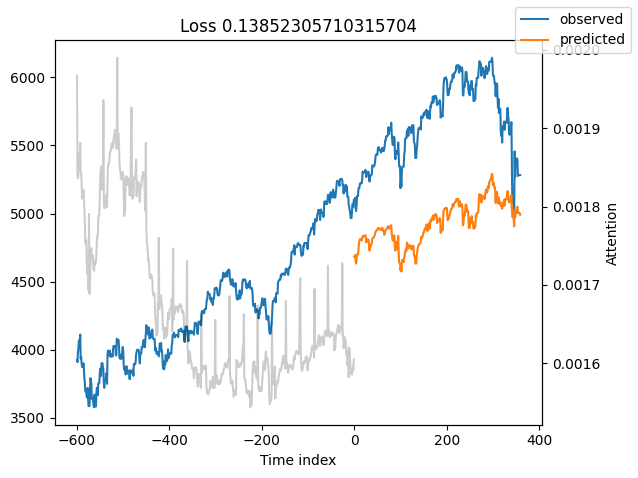

In [ ]:
from sklearn.metrics import r2_score

#Validation
val_predictions = best_tft.predict(val_loader, return_y=True, return_index=True)

raw_predictions = best_tft.predict(
    val_loader, mode="raw", return_x=True, return_y=True
)

y_actual = val_predictions.y[0]
y_actual_np = y_actual.cpu().numpy()
y_pred_np = val_predictions.output.cpu().numpy()
y_actual_np = y_actual_np.flatten()
y_pred_np = y_pred_np.flatten()
print("R2 Score: ", r2_score(y_actual_np, y_pred_np))
print("SMAPE",SMAPE()(val_predictions.output, val_predictions.y).cpu().numpy())
print("RMSE",RMSE()(val_predictions.output, val_predictions.y).cpu().numpy())

best_tft.plot_prediction(
    raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True
)

#Testing
test_predictions = best_tft.predict(test_loader, return_y=True, return_index=True)

raw_predictions = best_tft.predict(
    test_loader, mode="raw", return_x=True, return_y = True
)

y_actual = val_predictions.y[0]
y_actual_np = y_actual.cpu().numpy()
y_pred_np = val_predictions.output.cpu().numpy()
y_actual_np = y_actual_np.flatten()
y_pred_np = y_pred_np.flatten()
print("R2 Score: ", r2_score(y_actual_np, y_pred_np))
print("SMAPE",SMAPE()(test_predictions.output, test_predictions.y).cpu().numpy())
print("RMSE",RMSE()(test_predictions.output, test_predictions.y).cpu().numpy())

best_tft.plot_prediction(
    raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True
)